# EMD-ICA EEG Denoising — Evaluation on Test Split

**Pipeline:** Empirical Mode Decomposition (EMD) → Independent Component Analysis (FastICA) → Signal Reconstruction  
**Dataset:** EEGDenoiseNet-style HDF5 files (7 artifact combos × 3 splits)  
**Evaluated on:** test split only  
**Metrics:** MSE · RMSE · RRMSE · SNR (dB) · Spectral Loss

---
### How EMD-ICA works
1. **EMD** decomposes each noisy EEG segment into Intrinsic Mode Functions (IMFs)
2. **FastICA** is applied across the IMF matrix to separate statistically independent sources
3. **Artifact IMFs** are identified by correlation with a reference (highest-frequency IMF) or by kurtosis thresholding
4. **Reconstruction** sums the retained IMFs back to produce clean EEG

## 1 · Install dependencies

In [1]:
%%capture
!pip install EMD-signal scikit-learn h5py numpy scipy pandas matplotlib seaborn tqdm

## 2 · Imports & reproducibility

In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import h5py
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis
from sklearn.decomposition import FastICA
from PyEMD import EMD
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

print('All imports OK ✓')

All imports OK ✓


## 3 · Configuration

In [3]:
# ── Dataset path (Kaggle input) ───────────────────────────────────────────────
# Adjust this to your Kaggle dataset mount point
DATASET_DIR = '/kaggle/input/datasets/lucky3663/eegdenoise'   # ← change as needed

# ── Artifact combinations (matches your HDF5 file prefixes) ──────────────────
COMBOS = ['emg', 'eog', 'ecg', 'emg_eog', 'emg_ecg', 'eog_ecg', 'emg_eog_ecg']

# ── Signal parameters ─────────────────────────────────────────────────────────
FS        = 256          # sampling frequency (Hz)
SEG_LEN   = 512          # samples per segment

# ── EMD-ICA hyper-parameters ──────────────────────────────────────────────────
MAX_IMFS        = 8      # maximum IMFs to extract per segment
ICA_N_COMPONENTS = None  # None → use all IMFs
# Artifact component selection strategy:
#   'kurtosis'   → reject IMFs whose |kurtosis| > KURTOSIS_THRESH
#   'correlation'→ reject the IMF most correlated with the residual (highest freq)
SELECTION_STRATEGY = 'kurtosis'
KURTOSIS_THRESH    = 2.0

# ── Evaluation ────────────────────────────────────────────────────────────────
MAX_SAMPLES_PER_COMBO = None   # None → use all 4520 test rows; set integer to subsample

# ── Output directory ─────────────────────────────────────────────────────────
OUT_DIR = '/kaggle/working/results'
os.makedirs(OUT_DIR, exist_ok=True)

print(f'Config OK. Dataset dir: {DATASET_DIR}')
print(f'Combos: {COMBOS}')

Config OK. Dataset dir: /kaggle/input/datasets/lucky3663/eegdenoise
Combos: ['emg', 'eog', 'ecg', 'emg_eog', 'emg_ecg', 'eog_ecg', 'emg_eog_ecg']


## 4 · Data loader

In [4]:
def load_test_split(combo: str, dataset_dir: str, max_samples=None):
    """
    Load the test split HDF5 file for a given combo.
    Returns (clean, noisy) arrays of shape (N, 512).
    """
    path = os.path.join(dataset_dir, f'{combo}_test.h5')
    if not os.path.exists(path):
        raise FileNotFoundError(f'Test file not found: {path}')

    with h5py.File(path, 'r') as f:
        clean = f['clean'][:]
        noisy = f['noisy'][:]

    if max_samples is not None:
        idx = np.random.choice(len(clean), min(max_samples, len(clean)), replace=False)
        clean, noisy = clean[idx], noisy[idx]

    return clean.astype(np.float32), noisy.astype(np.float32)


# Quick sanity check on first combo
try:
    _c, _n = load_test_split(COMBOS[0], DATASET_DIR, max_samples=5)
    print(f'Sample load OK — clean {_c.shape}, noisy {_n.shape}, dtype {_c.dtype}')
except FileNotFoundError as e:
    print(f'[WARNING] {e}')
    print('Verify DATASET_DIR points to the correct Kaggle input folder.')

Sample load OK — clean (5, 512), noisy (5, 512), dtype float32


## 5 · Metric functions

In [5]:
def mse(clean, denoised):
    """Mean Squared Error."""
    return float(np.mean((clean - denoised) ** 2))


def rmse(clean, denoised):
    """Root Mean Squared Error."""
    return float(np.sqrt(mse(clean, denoised)))


def rrmse(clean, denoised):
    """
    Relative Root Mean Squared Error.
    RRMSE = RMSE(clean, denoised) / RMSE(clean, noisy)
    Values < 1 mean improvement over raw noisy signal.
    """
    rmse_model  = np.sqrt(np.mean((clean - denoised) ** 2))
    return float(rmse_model / (np.sqrt(np.mean(clean ** 2)) + 1e-12))


def snr_db(clean, denoised):
    """
    Signal-to-Noise Ratio in dB.
    SNR = 10 * log10(power(clean) / power(clean - denoised))
    """
    signal_power = np.mean(clean ** 2)
    noise_power  = np.mean((clean - denoised) ** 2)
    if noise_power < 1e-12:
        return float('inf')
    return float(10 * np.log10(signal_power / noise_power))


def spectral_loss(clean, denoised, fs=256):
    """
    Mean absolute difference between power spectra (dB scale).
    Measures how well the frequency content is preserved.
    """
    eps = 1e-12
    C = np.abs(rfft(clean))  ** 2
    D = np.abs(rfft(denoised)) ** 2
    loss = np.mean(np.abs(10 * np.log10(C + eps) - 10 * np.log10(D + eps)))
    return float(loss)


def compute_all_metrics(clean, denoised, fs=256):
    """Return dict of all metrics for a single segment pair."""
    return {
        'MSE'          : mse(clean, denoised),
        'RMSE'         : rmse(clean, denoised),
        'RRMSE'        : rrmse(clean, denoised),
        'SNR_dB'       : snr_db(clean, denoised),
        'Spectral_Loss': spectral_loss(clean, denoised, fs),
    }


print('Metric functions defined ✓')

Metric functions defined ✓


## 6 · EMD-ICA denoising core

In [6]:
def _identify_artifact_imfs_kurtosis(imfs, threshold=2.0):
    """
    Flag IMFs whose absolute excess kurtosis exceeds `threshold`.
    High kurtosis ≈ impulsive / non-Gaussian → likely artifact.
    Returns boolean mask: True = artifact IMF (to be removed).
    """
    kurt = np.array([abs(kurtosis(imf, fisher=True)) for imf in imfs])
    return kurt > threshold


def _identify_artifact_imfs_correlation(imfs):
    """
    Flag the highest-frequency IMF (IMF[0]) and any IMF with
    Pearson |r| > 0.5 with it — heuristic for EMG/ECG artifacts.
    Returns boolean mask.
    """
    reference = imfs[0]  # highest frequency IMF
    mask = np.zeros(len(imfs), dtype=bool)
    mask[0] = True       # always remove highest-freq IMF
    for i in range(1, len(imfs)):
        r = np.corrcoef(reference, imfs[i])[0, 1]
        if abs(r) > 0.5:
            mask[i] = True
    return mask


def emd_ica_denoise_segment(
    noisy: np.ndarray,
    fs: int = 256,
    max_imfs: int = 8,
    strategy: str = 'kurtosis',
    kurtosis_thresh: float = 2.0,
) -> np.ndarray:
    """
    Denoise a single EEG segment using EMD → ICA → reconstruction.

    Parameters
    ----------
    noisy          : (512,) contaminated EEG segment
    fs             : sampling rate
    max_imfs       : maximum number of IMFs to extract
    strategy       : 'kurtosis' or 'correlation'
    kurtosis_thresh: threshold for kurtosis-based rejection

    Returns
    -------
    denoised : (512,) reconstructed EEG segment
    """
    # ── Step 1: EMD decomposition ─────────────────────────────────────────────
    emd = EMD()
    emd.MAX_ITERATION = 100
    try:
        imfs = emd.emd(noisy, max_imf=max_imfs)  # shape: (n_imfs, 512)
    except Exception:
        return noisy.copy()   # fallback: return noisy if EMD fails

    if imfs.shape[0] < 2:
        # Not enough IMFs for ICA — return noisy
        return noisy.copy()

    # ── Step 2: FastICA on IMF matrix ────────────────────────────────────────
    # IMF matrix: rows = IMFs, cols = time samples → transpose for ICA
    n_imfs = imfs.shape[0]
    try:
        ica = FastICA(
            n_components=n_imfs,
            max_iter=500,
            tol=1e-4,
            random_state=42,
        )
        # ICA expects (n_samples, n_features) → (512, n_imfs)
        sources   = ica.fit_transform(imfs.T)     # (512, n_imfs)
        mixing    = ica.mixing_                   # (n_imfs, n_imfs)
        mean_     = ica.mean_                     # (n_imfs,)
    except Exception:
        # ICA failed (e.g. convergence) — fall back to kurtosis-only on raw IMFs
        sources  = imfs.T
        mixing   = np.eye(n_imfs)
        mean_    = np.zeros(n_imfs)

    # sources shape: (512, n_imfs)
    sources_T = sources.T  # (n_imfs, 512)

    # ── Step 3: Identify artifact independent components ──────────────────────
    if strategy == 'kurtosis':
        artifact_mask = _identify_artifact_imfs_kurtosis(sources_T, kurtosis_thresh)
    else:
        artifact_mask = _identify_artifact_imfs_correlation(sources_T)

    # Ensure at least one component is kept
    if artifact_mask.all():
        # Keep the component with lowest kurtosis (most Gaussian → most EEG-like)
        kurt_vals = np.array([abs(kurtosis(s, fisher=True)) for s in sources_T])
        artifact_mask[np.argmin(kurt_vals)] = False

    # ── Step 4: Zero out artifact components and reconstruct ──────────────────
    sources_clean = sources.copy()                     # (512, n_imfs)
    sources_clean[:, artifact_mask] = 0.0

    # Inverse ICA: X_reconstructed = sources_clean @ mixing.T + mean
    reconstructed_imfs = (sources_clean @ mixing.T + mean_).T  # (n_imfs, 512)

    # ── Step 5: Sum retained IMFs ─────────────────────────────────────────────
    denoised = reconstructed_imfs[~artifact_mask].sum(axis=0)   # (512,)

    return denoised.astype(np.float32)


print('EMD-ICA core function defined ✓')

EMD-ICA core function defined ✓


## 7 · Batch evaluation loop

In [7]:
def evaluate_combo(combo: str, dataset_dir: str, max_samples=None, fs=256,
                   max_imfs=8, strategy='kurtosis', kurtosis_thresh=2.0):
    """
    Run EMD-ICA on the test split of one combo.
    Returns a DataFrame of per-segment metrics + the first 5 denoised segments.
    """
    print(f'\n━━━ {combo.upper()} ━━━')
    clean_all, noisy_all = load_test_split(combo, dataset_dir, max_samples)
    N = len(clean_all)
    print(f'  Loaded {N} test segments')

    rows      = []
    denoised_examples = []

    for i in tqdm(range(N), desc=f'  Denoising [{combo}]', unit='seg',
                  ncols=90, colour='cyan'):
        noisy_seg = noisy_all[i]
        clean_seg = clean_all[i]

        denoised_seg = emd_ica_denoise_segment(
            noisy_seg,
            fs=fs,
            max_imfs=max_imfs,
            strategy=strategy,
            kurtosis_thresh=kurtosis_thresh,
        )

        m = compute_all_metrics(clean_seg, denoised_seg, fs=fs)
        m['combo'] = combo
        m['segment_idx'] = i
        rows.append(m)

        if len(denoised_examples) < 5:
            denoised_examples.append({
                'clean'   : clean_seg,
                'noisy'   : noisy_seg,
                'denoised': denoised_seg,
            })

    df = pd.DataFrame(rows)
    _print_summary(df, combo)
    return df, denoised_examples


def _print_summary(df, combo):
    cols = ['MSE', 'RMSE', 'RRMSE', 'SNR_dB', 'Spectral_Loss']
    summary = df[cols].agg(['mean', 'std', 'median'])
    print(f'\n  ── Summary for {combo} ──')
    print(summary.to_string(float_format='{:.4f}'.format))


print('Evaluation function defined ✓')

Evaluation function defined ✓


## 8 · Run evaluation across all combos

In [8]:
all_metrics   = []   # list of DataFrames, one per combo
all_examples  = {}   # dict: combo → list of 5 example dicts

for combo in COMBOS:
    try:
        df_combo, examples = evaluate_combo(
            combo,
            dataset_dir     = DATASET_DIR,
            max_samples     = MAX_SAMPLES_PER_COMBO,
            fs              = FS,
            max_imfs        = MAX_IMFS,
            strategy        = SELECTION_STRATEGY,
            kurtosis_thresh = KURTOSIS_THRESH,
        )
        all_metrics.append(df_combo)
        all_examples[combo] = examples
    except FileNotFoundError as e:
        print(f'[SKIP] {e}')

# ── Aggregate ─────────────────────────────────────────────────────────────────
results_df = pd.concat(all_metrics, ignore_index=True)
print(f'\n✓ Evaluation complete. Total segments evaluated: {len(results_df)}')


━━━ EMG ━━━
  Loaded 4520 test segments


  Denoising [emg]:   0%|                                        | 0/4520 [00:00<?, ?seg/s]


  ── Summary for emg ──
          MSE   RMSE  RRMSE  SNR_dB  Spectral_Loss
mean   0.5323 0.7007 1.7346 -3.3104        16.9918
std    0.2710 0.2033 1.1248  4.8509         6.7938
median 0.5192 0.7205 1.2589 -2.0000        16.0218

━━━ EOG ━━━
  Loaded 4520 test segments


  Denoising [eog]:   0%|                                        | 0/4520 [00:00<?, ?seg/s]


  ── Summary for eog ──
          MSE   RMSE  RRMSE  SNR_dB  Spectral_Loss
mean   0.4801 0.6605 1.5588 -2.7146         8.5655
std    0.2784 0.2092 0.9188  4.2228         6.0471
median 0.4419 0.6648 1.2298 -1.7969         7.2404

━━━ ECG ━━━
  Loaded 4520 test segments


...


  ── Summary for emg_ecg ──
          MSE   RMSE  RRMSE  SNR_dB  Spectral_Loss
mean   0.6366 0.7626 2.1742 -5.3436        16.0468
std    0.3668 0.2347 1.3536  4.7759         6.3238
median 0.5860 0.7655 1.6827 -4.5200        15.1760

━━━ EOG_ECG ━━━
  Loaded 4520 test segments


  Denoising [eog_ecg]:   0%|                                    | 0/4520 [00:00<?, ?seg/s]


  ── Summary for eog_ecg ──
          MSE   RMSE  RRMSE  SNR_dB  Spectral_Loss
mean   0.5792 0.7214 1.9688 -4.6535        10.9608
std    0.3549 0.2424 1.1831  4.4117         7.2367
median 0.5511 0.7424 1.5261 -3.6719         9.5982

━━━ EMG_EOG_ECG ━━━
  Loaded 4520 test segments


  Denoising [emg_eog_ecg]:   0%|                                | 0/4520 [00:00<?, ?seg/s]


  ── Summary for emg_eog_ecg ──
          MSE   RMSE  RRMSE  SNR_dB  Spectral_Loss
mean   0.6079 0.7492 2.6245 -6.8622        15.8992
std    0.3108 0.2158 1.6778  5.0131         6.5334
median 0.5862 0.7656 2.0452 -6.2147        14.9106

✓ Evaluation complete. Total segments evaluated: 31640


## 9 · Aggregate results table

In [9]:
METRIC_COLS = ['MSE', 'RMSE', 'RRMSE', 'SNR_dB', 'Spectral_Loss']

summary_table = (
    results_df
    .groupby('combo')[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)

# Flatten multi-level columns
summary_table.columns = [f'{m}_{s}' for m, s in summary_table.columns]
summary_table = summary_table.reset_index()

# Reorder rows to match COMBOS order
summary_table['combo'] = pd.Categorical(summary_table['combo'], categories=COMBOS, ordered=True)
summary_table = summary_table.sort_values('combo').reset_index(drop=True)

print('=== EMD-ICA Evaluation Results (Test Split) ===')
display(summary_table)

# Save CSV
summary_path = os.path.join(OUT_DIR, 'emd_ica_results_summary.csv')
summary_table.to_csv(summary_path, index=False)
print(f'\nSaved → {summary_path}')

=== EMD-ICA Evaluation Results (Test Split) ===


,combo,MSE_mean,MSE_std,RMSE_mean,RMSE_std,RRMSE_mean,RRMSE_std,SNR_dB_mean,SNR_dB_std,Spectral_Loss_mean,Spectral_Loss_std
0,emg,0.5323,0.2710,0.7007,0.2033,1.7346,1.1248,-3.3104,4.8509,16.9918,6.7938
1,eog,0.4801,0.2784,0.6605,0.2092,1.5588,0.9188,-2.7146,4.2228,8.5655,6.0471
2,ecg,0.9920,1.3398,0.8886,0.4500,1.5664,0.8744,-2.8359,4.1068,11.3600,7.4078
3,emg_eog,0.5161,0.2545,0.6906,0.1978,2.1947,1.4148,-5.3364,4.9139,16.1685,6.7067
4,emg_ecg,0.6366,0.3668,0.7626,0.2347,2.1742,1.3536,-5.3436,4.7759,16.0468,6.3238
5,eog_ecg,0.5792,0.3549,0.7214,0.2424,1.9688,1.1831,-4.6535,4.4117,10.9608,7.2367
6,emg_eog_ecg,0.6079,0.3108,0.7492,0.2158,2.6245,1.6778,-6.8622,5.0131,15.8992,6.5334



Saved → /kaggle/working/results/emd_ica_results_summary.csv


## 10 · Visualisation — Metric comparison across combos

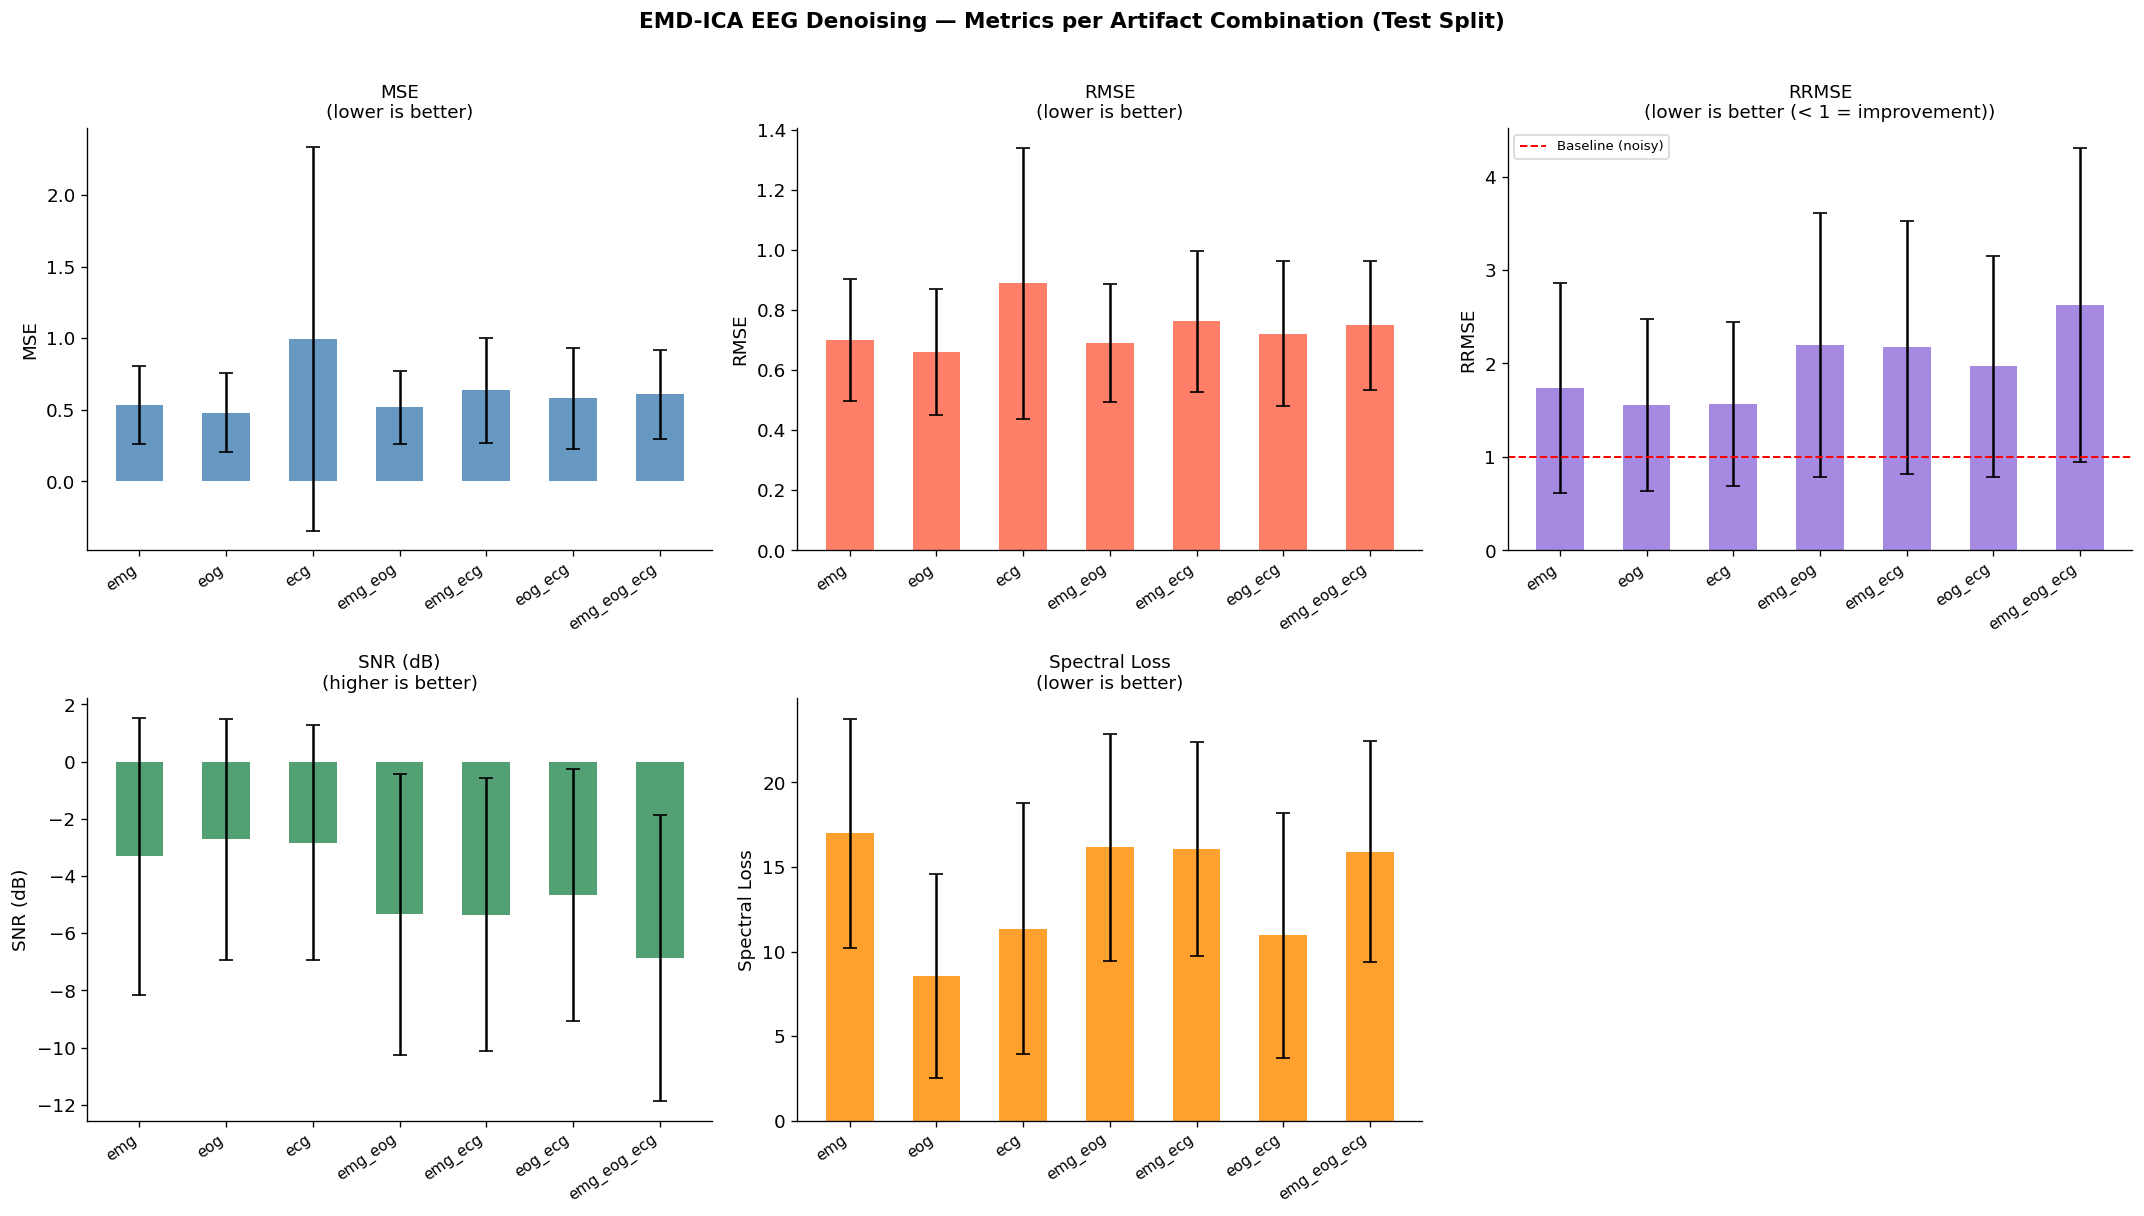

Saved metric_comparison.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metric_meta = {
    'MSE'          : ('MSE',            'lower is better', 'steelblue'),
    'RMSE'         : ('RMSE',           'lower is better', 'tomato'),
    'RRMSE'        : ('RRMSE',          'lower is better (< 1 = improvement)', 'mediumpurple'),
    'SNR_dB'       : ('SNR (dB)',        'higher is better', 'seagreen'),
    'Spectral_Loss': ('Spectral Loss',  'lower is better', 'darkorange'),
}

for ax, (metric, (label, direction, colour)) in zip(axes, metric_meta.items()):
    means = summary_table.set_index('combo')[f'{metric}_mean']
    stds  = summary_table.set_index('combo')[f'{metric}_std']
    x     = np.arange(len(COMBOS))
    combos_present = [c for c in COMBOS if c in means.index]

    ax.bar(
        range(len(combos_present)),
        [means[c] for c in combos_present],
        yerr=[stds[c] for c in combos_present],
        color=colour, alpha=0.82, capsize=4, width=0.55,
    )
    ax.set_xticks(range(len(combos_present)))
    ax.set_xticklabels(combos_present, rotation=35, ha='right', fontsize=9)
    ax.set_title(f'{label}\n({direction})', fontsize=11)
    ax.set_ylabel(label)

    if metric == 'RRMSE':
        ax.axhline(1.0, color='red', ls='--', lw=1.2, label='Baseline (noisy)')
        ax.legend(fontsize=8)

axes[-1].set_visible(False)  # hide 6th subplot
fig.suptitle('EMD-ICA EEG Denoising — Metrics per Artifact Combination (Test Split)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'metric_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved metric_comparison.png')

## 11 · Visualisation — Distribution (box plots)

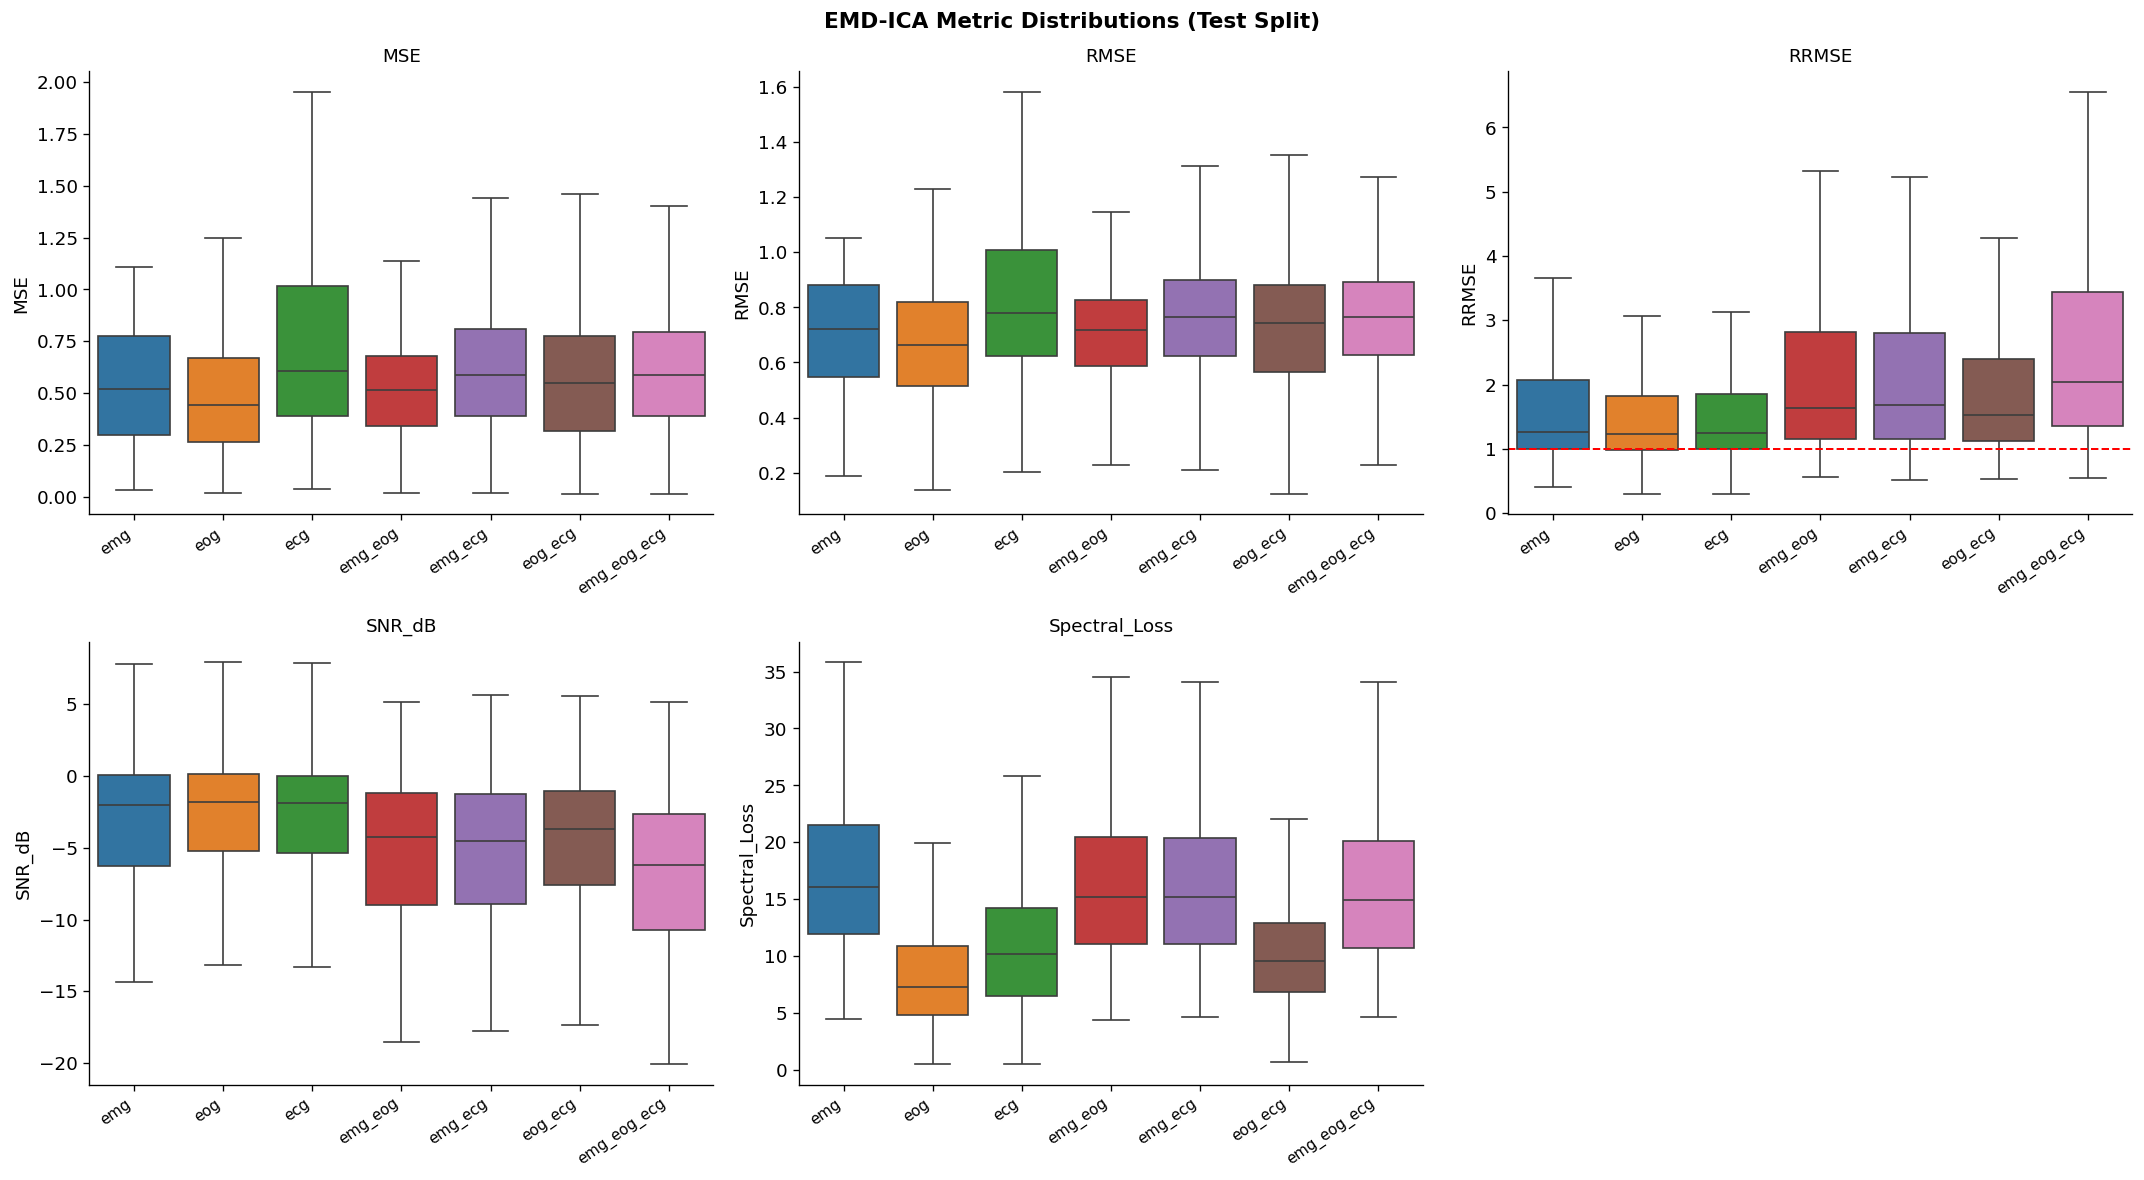

Saved metric_distributions.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, metric in zip(axes, METRIC_COLS):
    sns.boxplot(
        data=results_df,
        x='combo', y=metric,
        order=COMBOS,
        palette='tab10',
        showfliers=False,
        ax=ax,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel('')
    if metric == 'RRMSE':
        ax.axhline(1.0, color='red', ls='--', lw=1.2)

axes[-1].set_visible(False)
fig.suptitle('EMD-ICA Metric Distributions (Test Split)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'metric_distributions.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved metric_distributions.png')

## 12 · Visualisation — Waveform examples (one per combo)

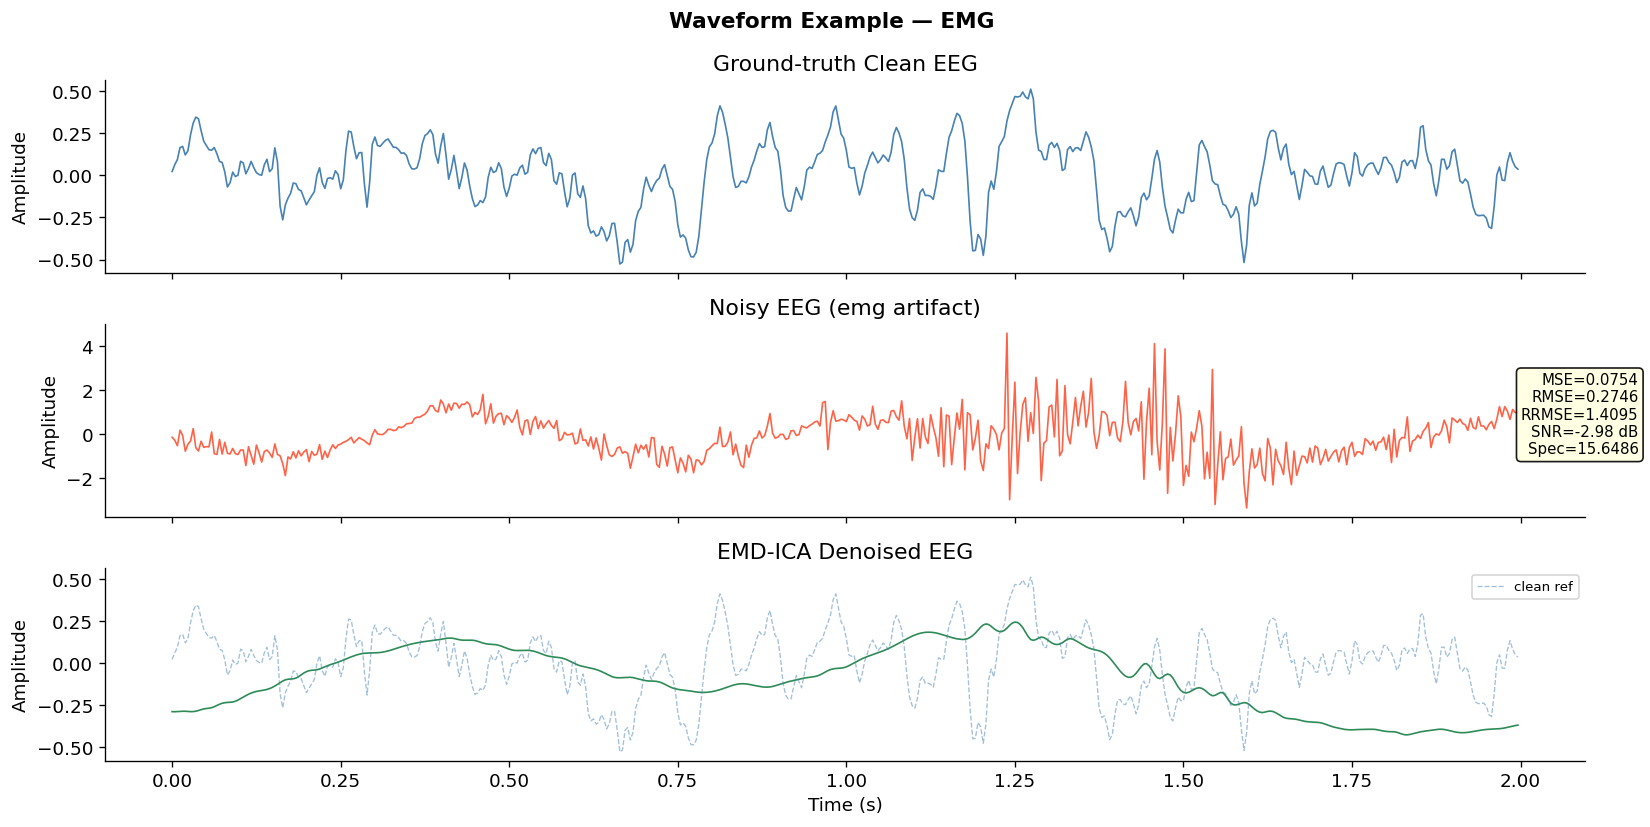

Saved /kaggle/working/results/waveform_emg.png


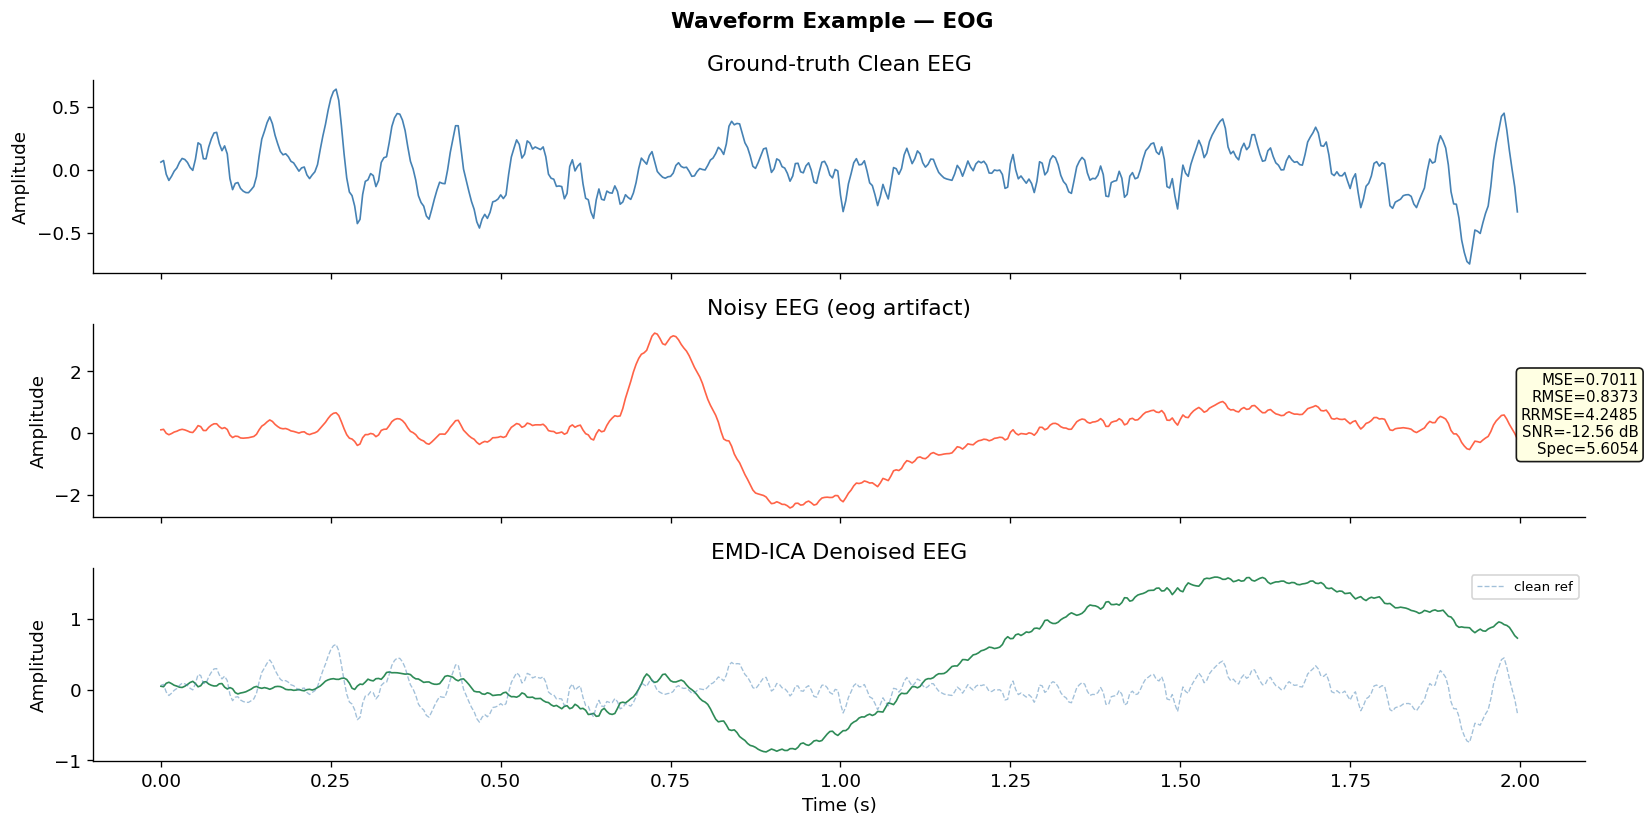

Saved /kaggle/working/results/waveform_eog.png


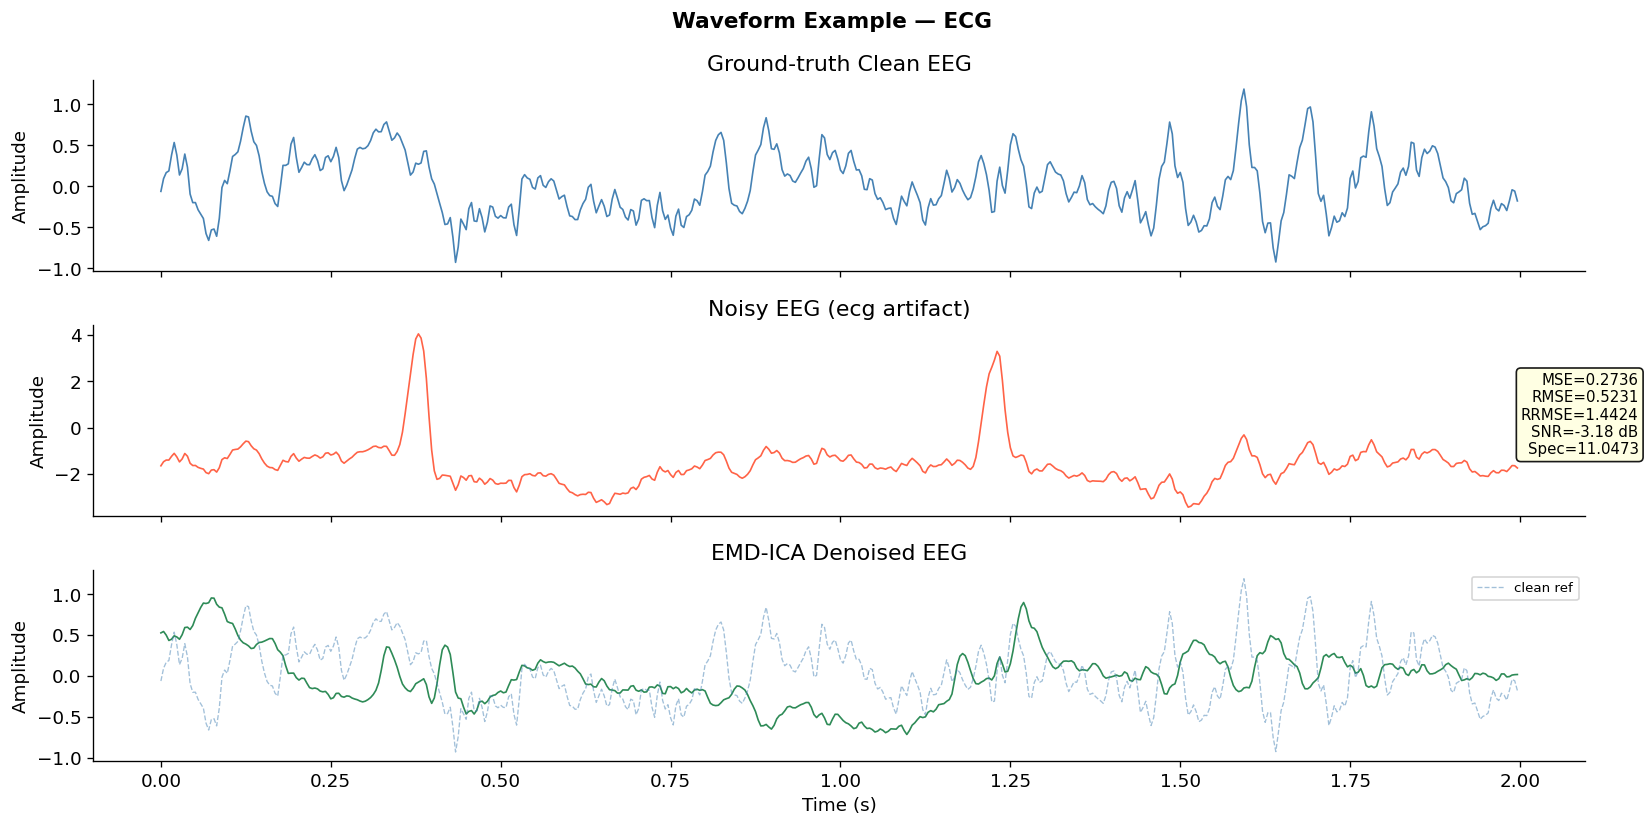

Saved /kaggle/working/results/waveform_ecg.png


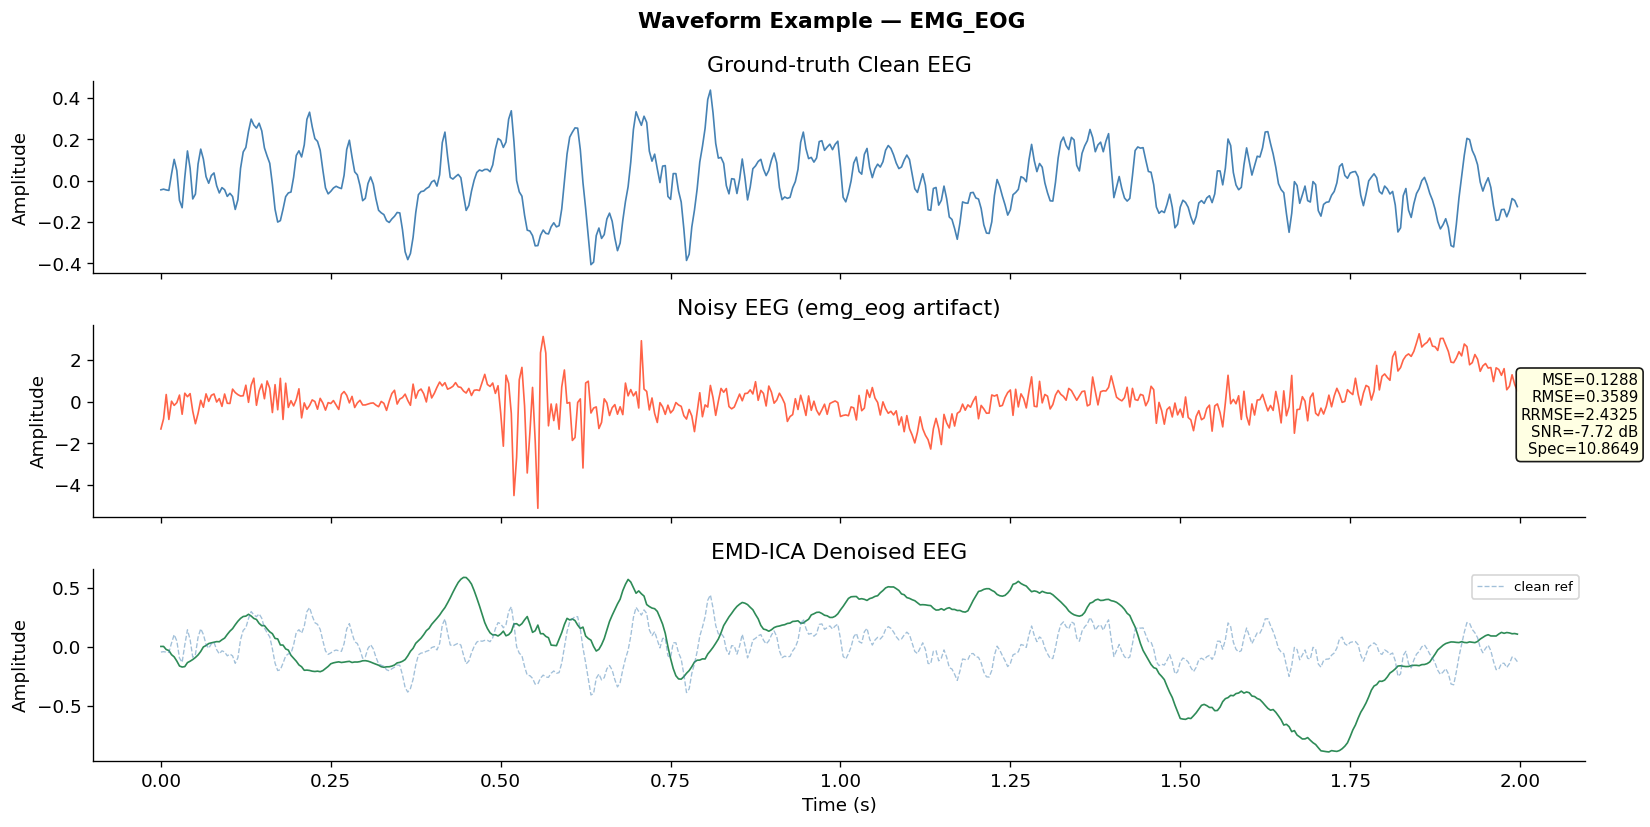

Saved /kaggle/working/results/waveform_emg_eog.png


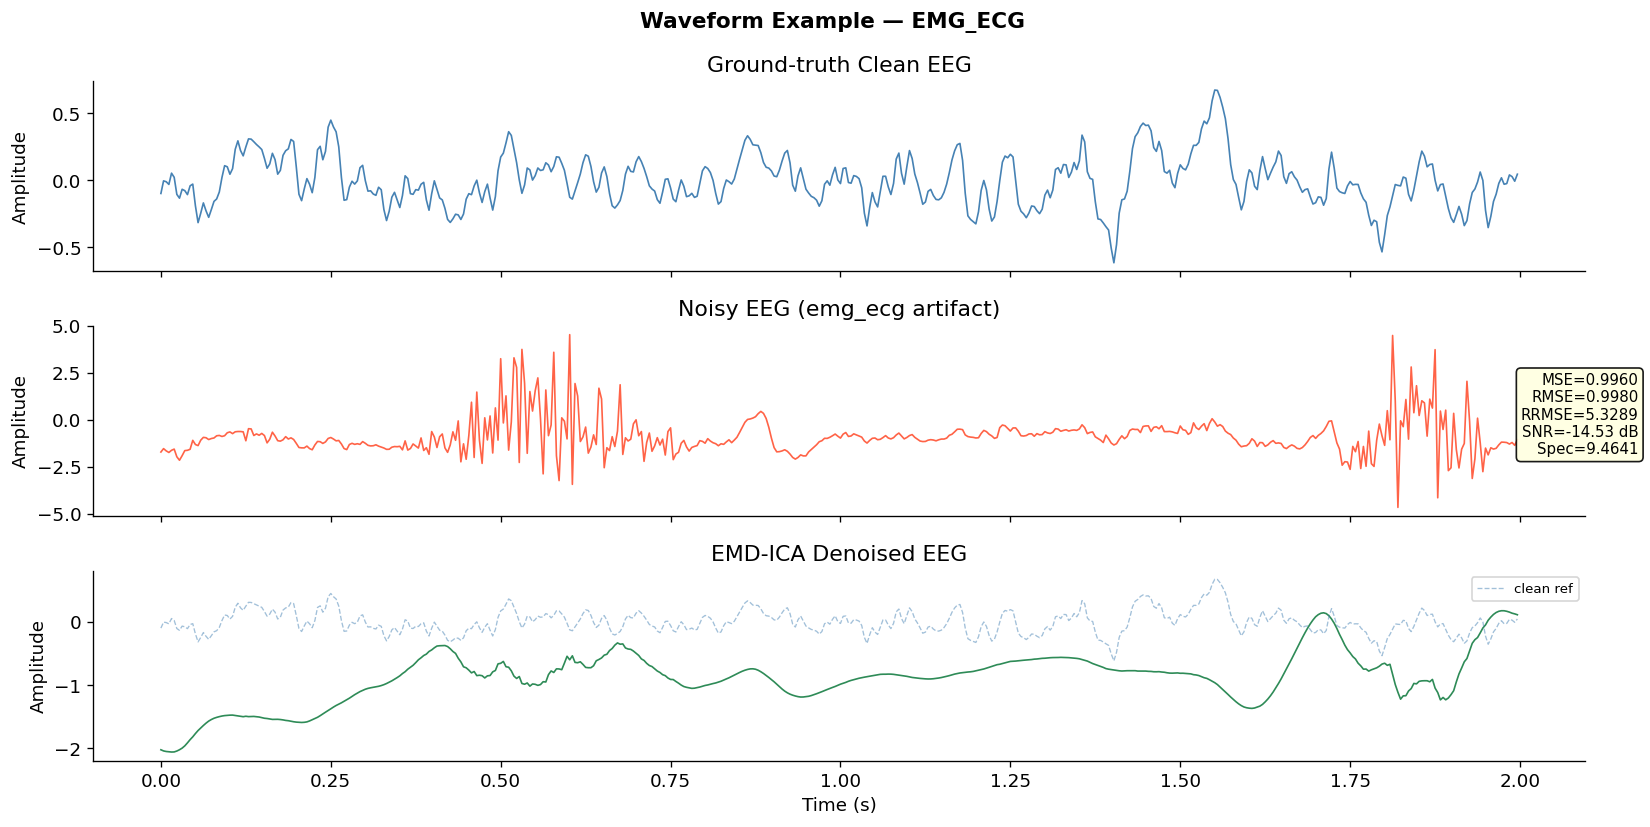

Saved /kaggle/working/results/waveform_emg_ecg.png


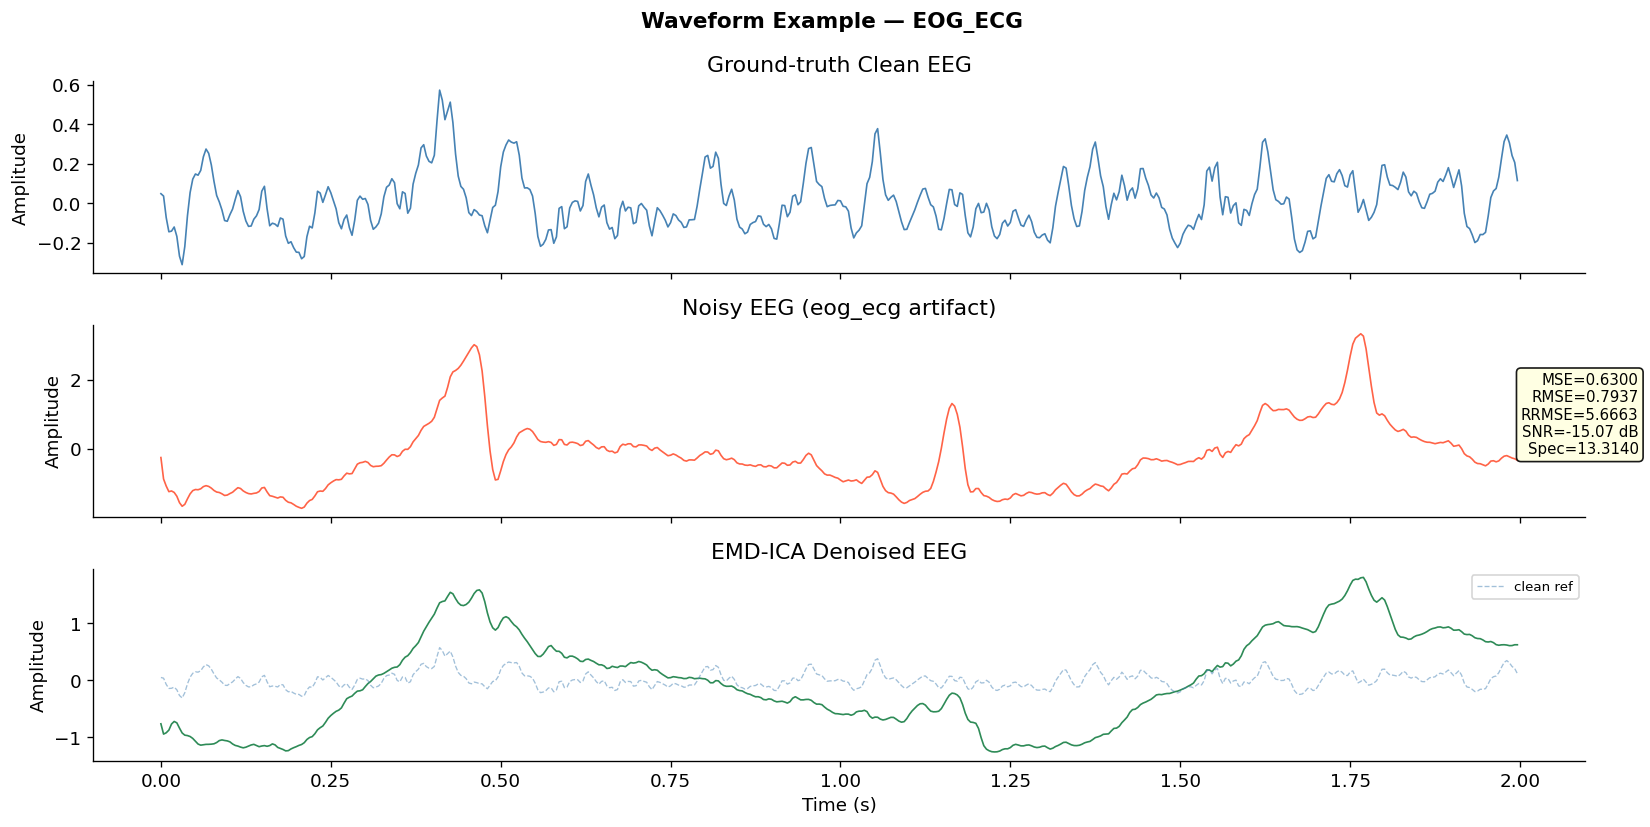

Saved /kaggle/working/results/waveform_eog_ecg.png


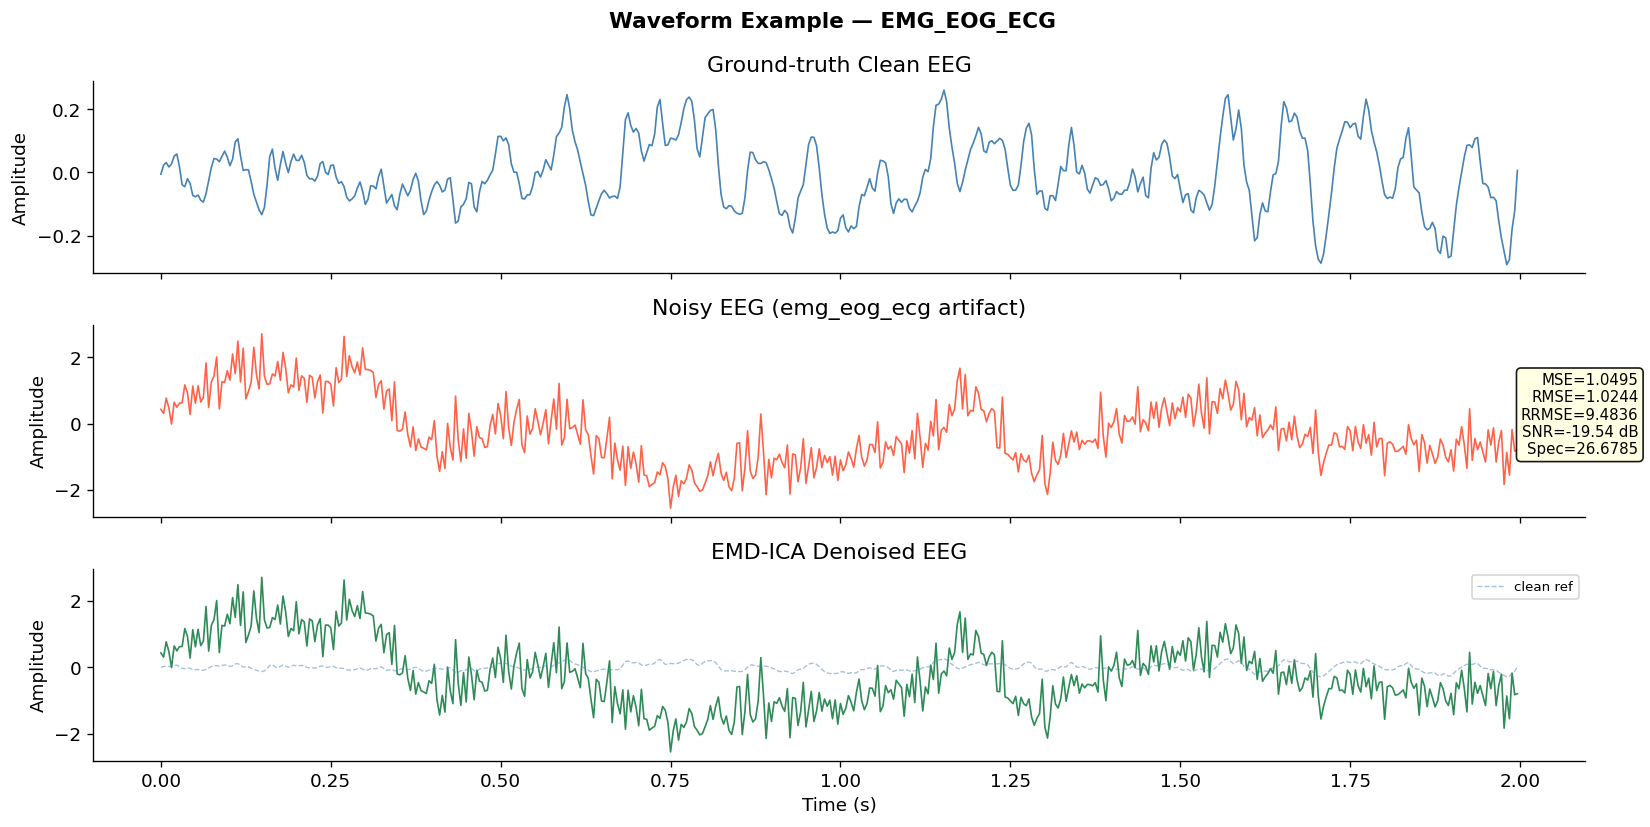

Saved /kaggle/working/results/waveform_emg_eog_ecg.png


In [12]:
t = np.arange(SEG_LEN) / FS  # time axis in seconds

for combo, examples in all_examples.items():
    ex = examples[0]   # first example segment
    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

    axes[0].plot(t, ex['clean'],    color='steelblue', lw=1.0)
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title('Ground-truth Clean EEG')

    axes[1].plot(t, ex['noisy'],    color='tomato',    lw=1.0)
    axes[1].set_ylabel('Amplitude')
    axes[1].set_title(f'Noisy EEG ({combo} artifact)')

    axes[2].plot(t, ex['denoised'], color='seagreen',  lw=1.0)
    axes[2].plot(t, ex['clean'],    color='steelblue', lw=0.8, alpha=0.5, ls='--', label='clean ref')
    axes[2].set_ylabel('Amplitude')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_title('EMD-ICA Denoised EEG')
    axes[2].legend(fontsize=8)

    # Annotate with metrics
    m = compute_all_metrics(ex['clean'], ex['denoised'], fs=FS)
    fig.text(0.98, 0.5,
             f"MSE={m['MSE']:.4f}\nRMSE={m['RMSE']:.4f}\nRRMSE={m['RRMSE']:.4f}"
             f"\nSNR={m['SNR_dB']:.2f} dB\nSpec={m['Spectral_Loss']:.4f}",
             va='center', ha='right', fontsize=9,
             bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

    fig.suptitle(f'Waveform Example — {combo.upper()}', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 0.96, 1])
    save_path = os.path.join(OUT_DIR, f'waveform_{combo}.png')
    fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved {save_path}')

## 13 · Visualisation — Power spectral density comparison

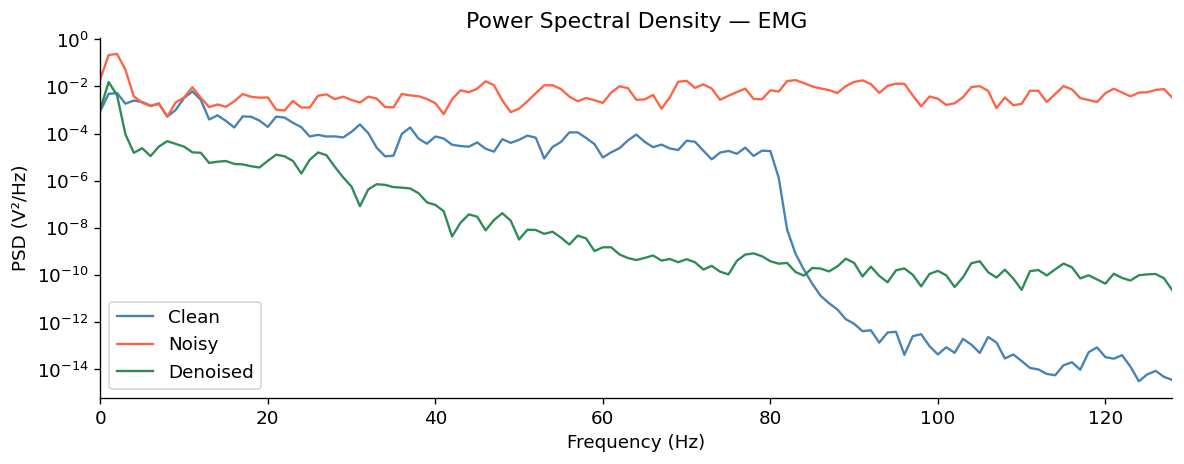

PSD plot saved for emg


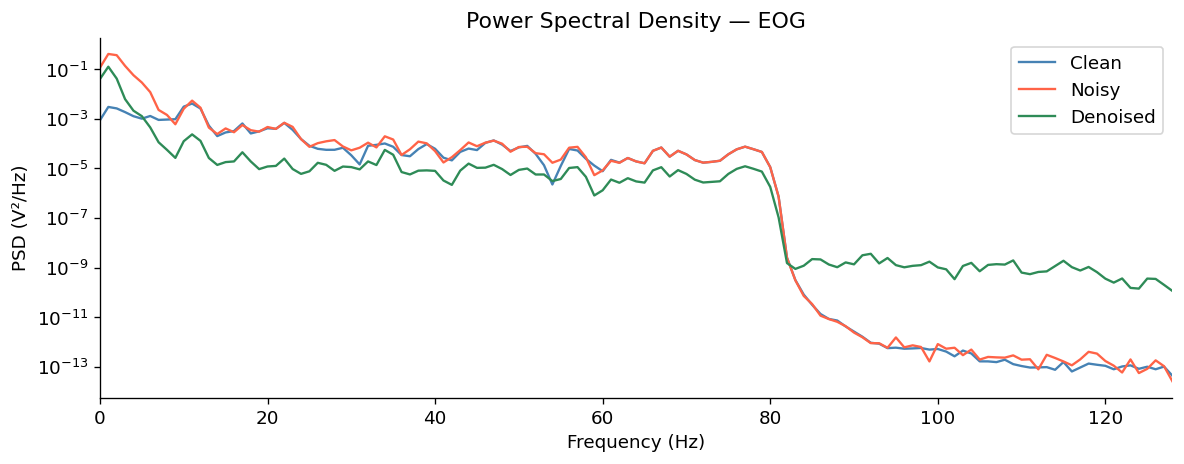

PSD plot saved for eog


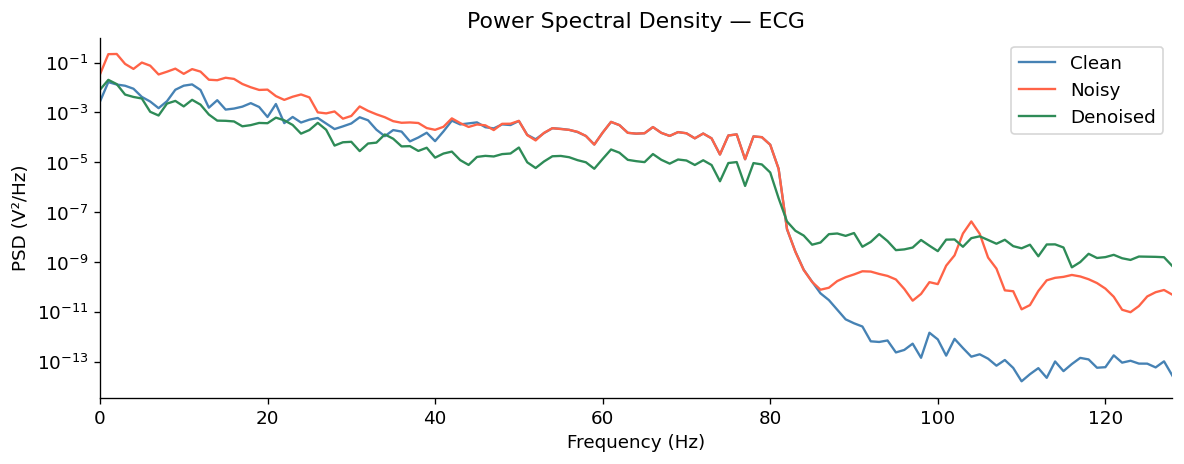

PSD plot saved for ecg


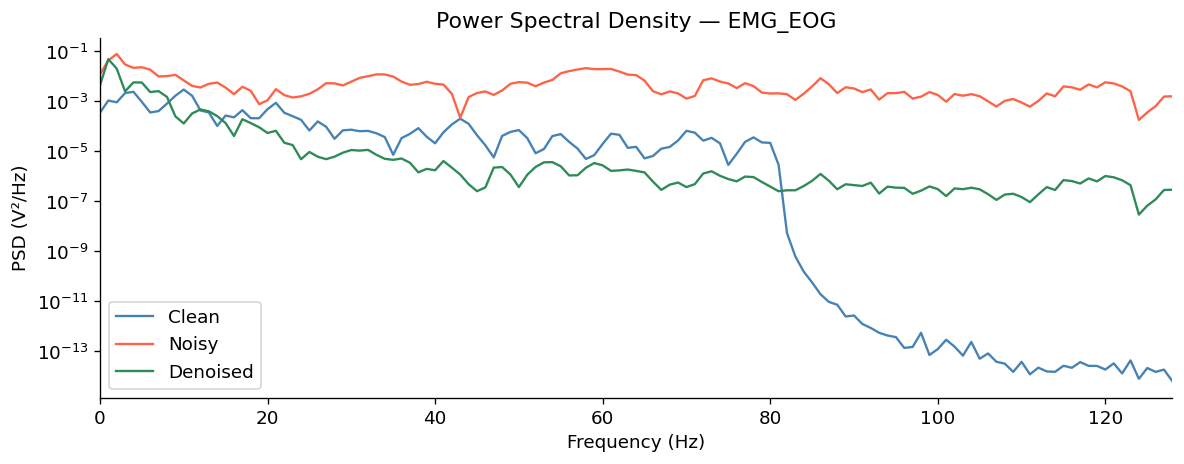

PSD plot saved for emg_eog


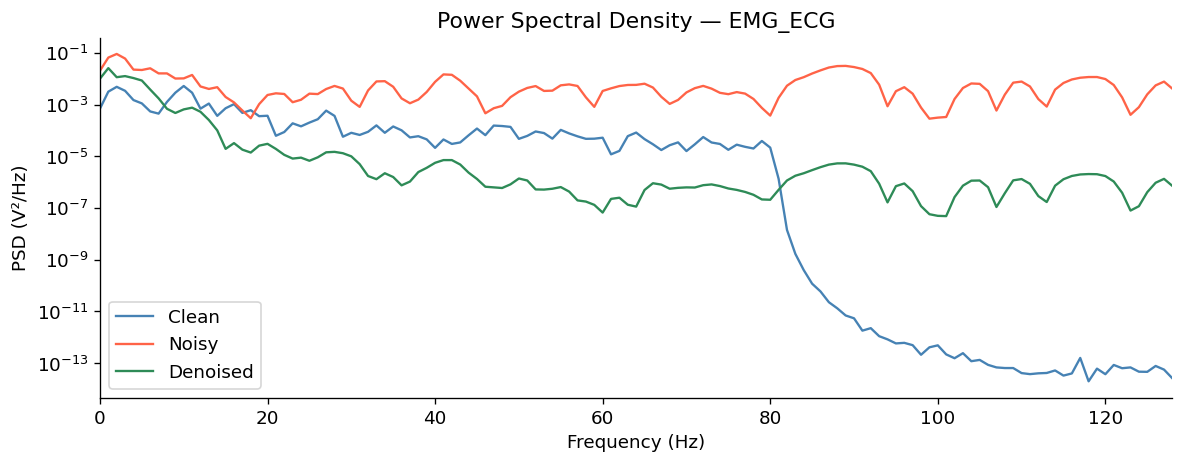

PSD plot saved for emg_ecg


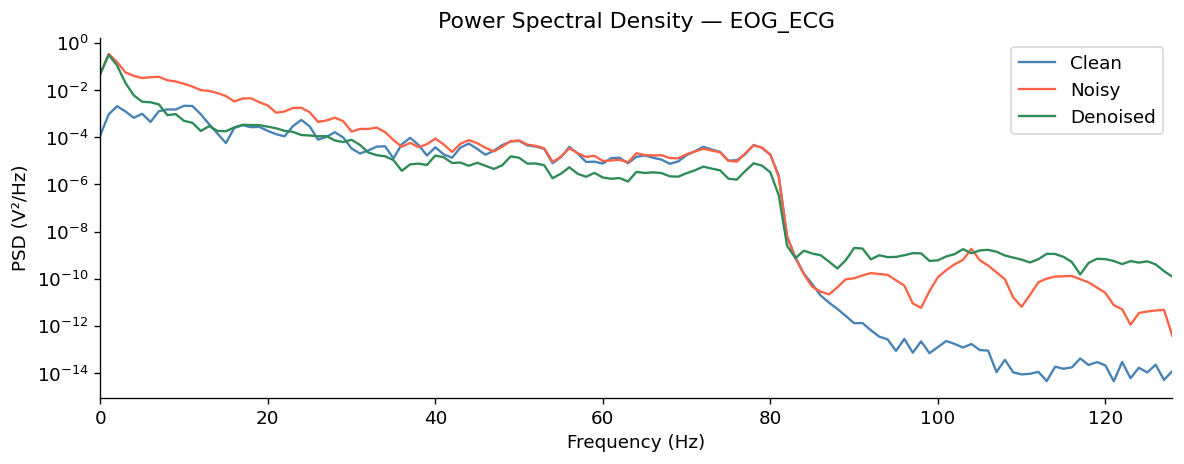

PSD plot saved for eog_ecg


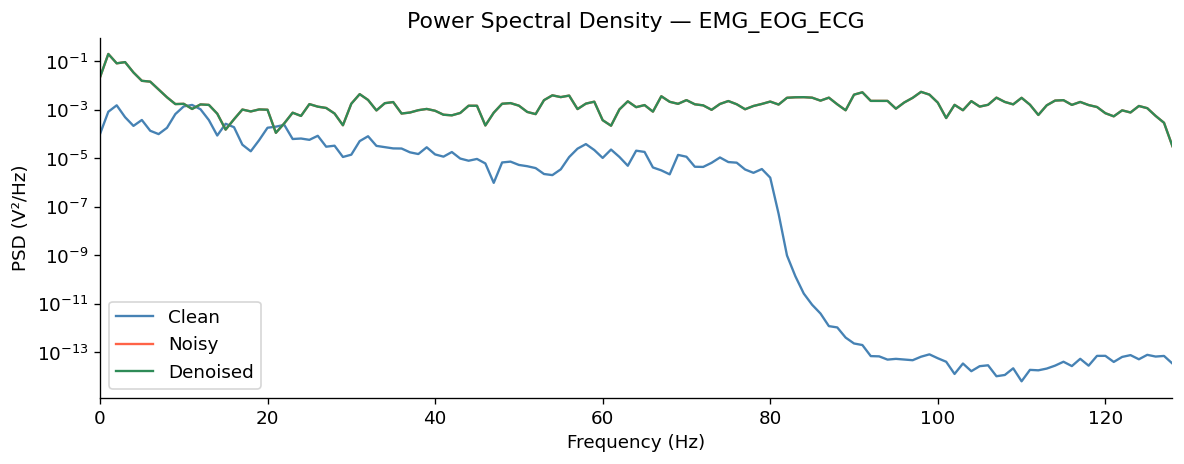

PSD plot saved for emg_eog_ecg


In [13]:
from scipy.signal import welch

def plot_psd_comparison(combo, examples, fs=256, out_dir=None):
    ex   = examples[0]
    fig, ax = plt.subplots(figsize=(10, 4))

    for sig, label, colour in [
        (ex['clean'],    'Clean',    'steelblue'),
        (ex['noisy'],    'Noisy',    'tomato'),
        (ex['denoised'], 'Denoised', 'seagreen'),
    ]:
        f, pxx = welch(sig, fs=fs, nperseg=min(256, SEG_LEN))
        ax.semilogy(f, pxx, label=label, lw=1.4, color=colour)

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (V²/Hz)')
    ax.set_title(f'Power Spectral Density — {combo.upper()}')
    ax.legend()
    ax.set_xlim(0, fs // 2)
    plt.tight_layout()
    if out_dir:
        fig.savefig(os.path.join(out_dir, f'psd_{combo}.png'), bbox_inches='tight', dpi=150)
    plt.show()


for combo, examples in all_examples.items():
    plot_psd_comparison(combo, examples, fs=FS, out_dir=OUT_DIR)
    print(f'PSD plot saved for {combo}')

## 14 · Heatmap — Mean metrics across combos

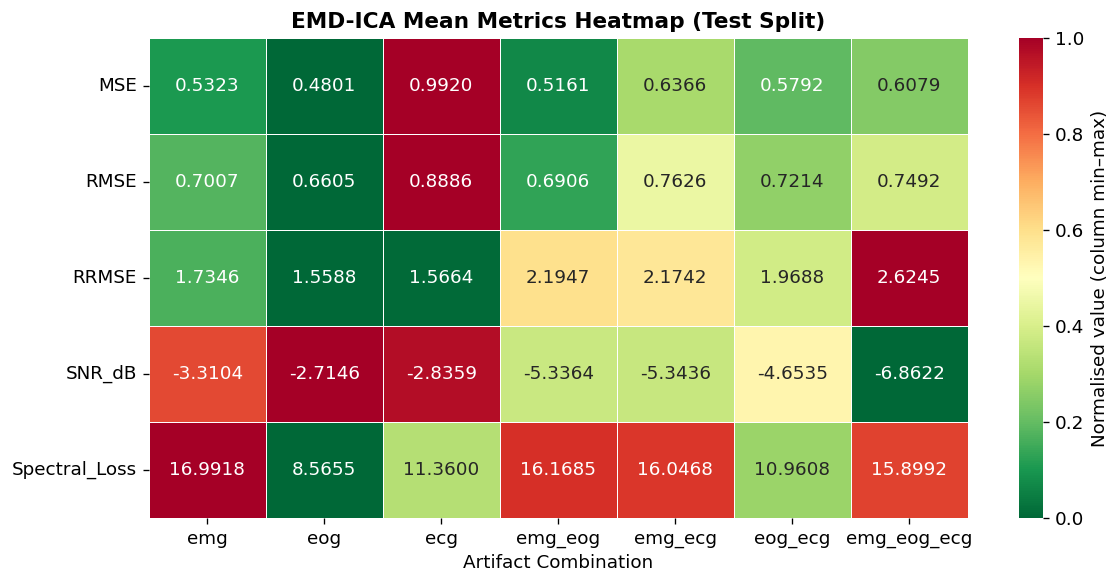

Saved metric_heatmap.png


In [14]:
heat_df = (
    results_df
    .groupby('combo')[METRIC_COLS]
    .mean()
    .reindex(COMBOS)
)

# Normalise each metric to [0, 1] for visual comparison
heat_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min() + 1e-12)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heat_norm.T,
    annot=heat_df.T.round(4),
    fmt='.4f',
    cmap='RdYlGn_r',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Normalised value (column min–max)'},
)
ax.set_title('EMD-ICA Mean Metrics Heatmap (Test Split)', fontsize=13, fontweight='bold')
ax.set_xlabel('Artifact Combination')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'metric_heatmap.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved metric_heatmap.png')

## 15 · Save full per-segment results

In [15]:
full_path = os.path.join(OUT_DIR, 'emd_ica_per_segment_results.csv')
results_df.to_csv(full_path, index=False)
print(f'Full per-segment results saved → {full_path}')
print(f'Shape: {results_df.shape}')
display(results_df.head(10))

Full per-segment results saved → /kaggle/working/results/emd_ica_per_segment_results.csv
Shape: (31640, 7)


,MSE,RMSE,RRMSE,SNR_dB,Spectral_Loss,combo,segment_idx
0,0.075424,0.274635,1.409486,-2.981216,15.648561,emg,0
1,0.287932,0.536593,2.216835,-6.914666,12.673759,emg,1
2,0.381085,0.617321,2.066067,-6.302886,13.957432,emg,2
3,0.279304,0.528492,1.446053,-3.203685,12.413371,emg,3
4,0.345648,0.587918,1.331949,-2.489752,14.504272,emg,4
5,0.373494,0.611142,1.165841,-1.332786,12.925735,emg,5
6,0.239285,0.489168,0.802327,1.912975,11.168674,emg,6
7,0.510438,0.714449,1.031958,-0.273239,29.613167,emg,7
8,0.468267,0.684300,0.892525,0.987592,12.532725,emg,8
9,0.417003,0.645758,0.778904,2.170322,14.239854,emg,9


## 16 · Final summary printout

In [16]:
print('=' * 65)
print('  EMD-ICA EEG DENOISING — FINAL RESULTS (TEST SPLIT)')
print('=' * 65)
print(f'  Strategy         : {SELECTION_STRATEGY}')
if SELECTION_STRATEGY == 'kurtosis':
    print(f'  Kurtosis thresh  : {KURTOSIS_THRESH}')
print(f'  Max IMFs         : {MAX_IMFS}')
print(f'  Sampling rate    : {FS} Hz')
print(f'  Segment length   : {SEG_LEN} samples ({SEG_LEN/FS:.3f} s)')
print(f'  Total segments   : {len(results_df)}')
print('-' * 65)

agg = results_df.groupby('combo')[METRIC_COLS].mean().reindex(COMBOS)
print(agg.round(5).to_string())
print('=' * 65)
print(f'\nAll outputs saved to: {OUT_DIR}')
for f in sorted(os.listdir(OUT_DIR)):
    print(f'  {f}')

  EMD-ICA EEG DENOISING — FINAL RESULTS (TEST SPLIT)
  Strategy         : kurtosis
  Kurtosis thresh  : 2.0
  Max IMFs         : 8
  Sampling rate    : 256 Hz
  Segment length   : 512 samples (2.000 s)
  Total segments   : 31640
-----------------------------------------------------------------
                 MSE     RMSE    RRMSE   SNR_dB  Spectral_Loss
combo                                                         
emg          0.53233  0.70071  1.73459 -3.31042       16.99175
eog          0.48007  0.66053  1.55880 -2.71457        8.56550
ecg          0.99200  0.88858  1.56640 -2.83586       11.36003
emg_eog      0.51606  0.69060  2.19472 -5.33644       16.16853
emg_ecg      0.63657  0.76256  2.17415 -5.34357       16.04680
eog_ecg      0.57917  0.72140  1.96880 -4.65353       10.96075
emg_eog_ecg  0.60793  0.74924  2.62451 -6.86221       15.89916

All outputs saved to: /kaggle/working/results
  emd_ica_per_segment_results.csv
  emd_ica_results_summary.csv
  metric_comparison.png
  m

In [17]:
!zip -r emd_ica_results.zip results

  adding: results/ (stored 0%)
  adding: results/metric_heatmap.png (deflated 6%)
  adding: results/metric_comparison.png (deflated 22%)
  adding: results/waveform_eog_ecg.png (deflated 5%)
  adding: results/emd_ica_results_summary.csv (deflated 47%)
  adding: results/psd_emg.png (deflated 5%)
  adding: results/psd_emg_eog_ecg.png (deflated 7%)
  adding: results/metric_distributions.png (deflated 23%)
  adding: results/psd_eog.png (deflated 6%)
  adding: results/waveform_ecg.png (deflated 4%)
  adding: results/waveform_emg_eog.png (deflated 4%)
  adding: results/emd_ica_per_segment_results.csv (deflated 56%)
  adding: results/waveform_emg.png (deflated 4%)
  adding: results/psd_eog_ecg.png (deflated 6%)
  adding: results/psd_ecg.png (deflated 5%)
  adding: results/waveform_emg_eog_ecg.png (deflated 4%)
  adding: results/psd_emg_eog.png (deflated 5%)
  adding: results/waveform_eog.png (deflated 6%)
  adding: results/psd_emg_ecg.png (deflated 6%)
  adding: results/waveform_emg_ecg.png (d